Analisis yang akan dilakukan berdasarkan [Sumber Dataset](https://mavenanalytics.io/data-playground/toy-store-e-commerce-database) :

- Bagaimana tren jumlah kunjungan/sesi di website dan volume pesanan?
- Berapa tingkat konversi dari kunjungan website menjadi pesanan? Bagaimana trennya dari waktu ke waktu?
- Saluran pemasaran (marketing channel) mana yang paling berhasil/efektif?
- Bagaimana perkembangan pendapatan rata-rata per pesanan? Bagaimana dengan pendapatan rata-rata per kunjungan/sesi website?

# Persiapan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

# Data Wrangling

## Gathering Data

### Dictionary Setiap Kolom di Dataset

In [4]:
maven_fuzzy_factory_data_dictionary_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/maven_fuzzy_factory_data_dictionary.csv")
maven_fuzzy_factory_data_dictionary_df

,Table,Field,Description
0,orders,order_id,Unique identifier for each order (PK)
1,orders,created_at,Timestamp when the order was placed
2,orders,website_session_id,Unique identifier for the website session (FK)
3,orders,user_id,Unique identifier for the user (FK)
4,orders,primary_product_id,Unique identifier for the primary product in the order if part of a bundle (FK)
5,orders,items_purchased,Number of items in the order
6,orders,price_usd,Total price for the items in the order
7,orders,cogs_usd,Cost of goods sold for the items in the order
8,order_items,order_item_id,Unique identifier for each order item (PK)
9,order_items,created_at,Timestamp when the order was placed


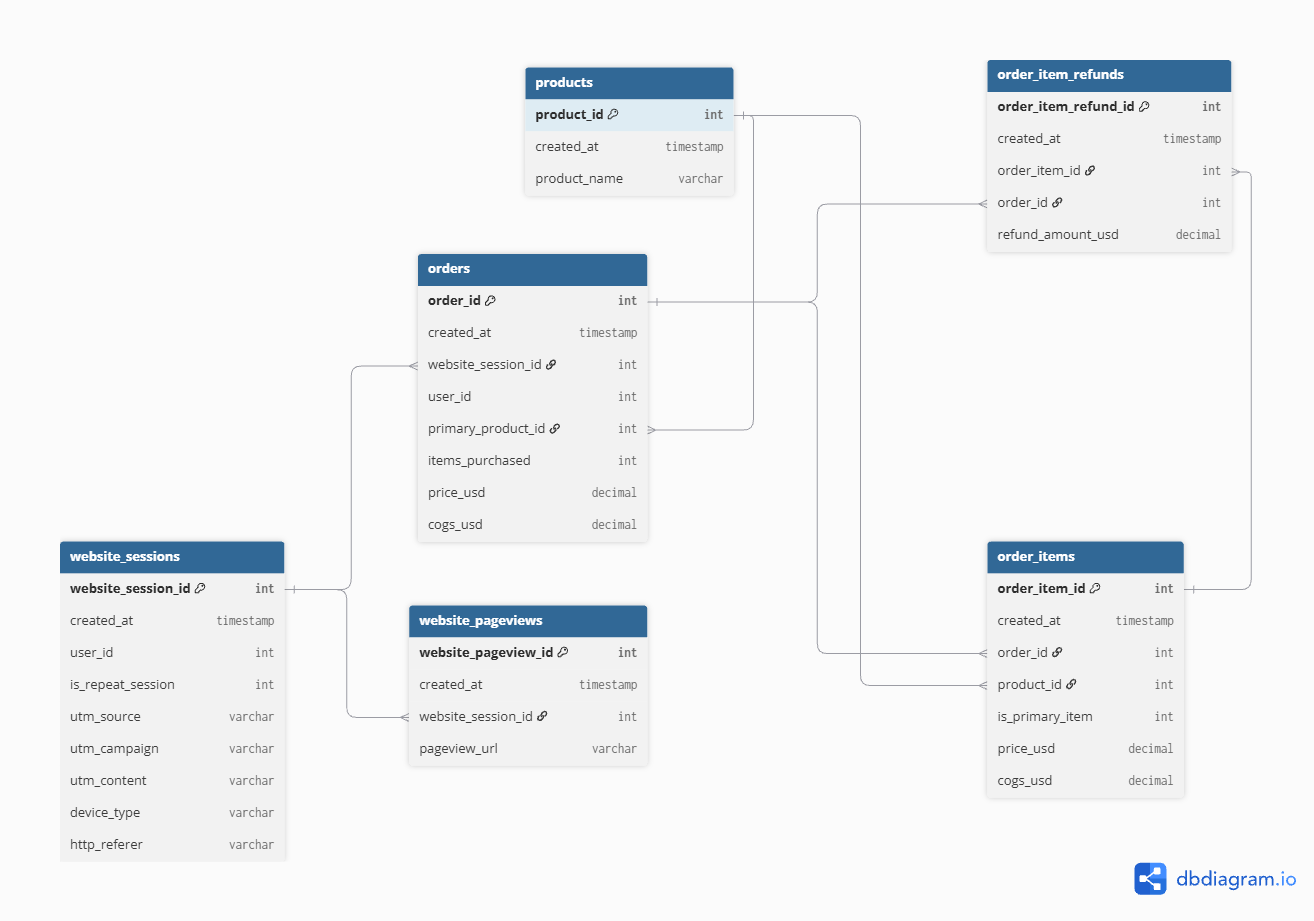

### Tabel Orders


Tabel ini mencatat ringkasan total dari sebuah transaksi/pembelian yang berhasil.

In [9]:
orders_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/orders.csv")
orders_df.head()


,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


### Tabel Order Item

Tabel ini mencatat transaksi/pembelian yang berhasil per order item.


In [7]:
order_items_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/order_items.csv")
order_items_df.head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49


**Bedanya dengan tabel orders?**

Dapat dilihat dibawah ini pada tabel `orders`.  
Pada `order_id` nomor ke-7300, catatan HANYA MENULISKAN bahwa memesan sebanyak 2 buah item tanpa detail barang apa yang dibeli

In [15]:
orders_df[orders_df['items_purchased'] > 1].head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
7299,7300,2013-09-25 08:49:13,132876,116186,1,2,109.98,41.98
7301,7302,2013-09-25 12:50:39,132965,116266,1,2,109.98,41.98
7309,7310,2013-09-25 17:30:15,133099,116378,1,2,109.98,41.98
7351,7352,2013-09-27 01:40:13,133588,103416,2,2,109.98,41.98
7375,7376,2013-09-28 10:21:27,133996,88820,1,2,109.98,41.98


Sedangkan pada tabel `order_item`, dapat dilihat dengan detail barang yang dibeli pada `order_id` ke 7300 adalah `product_id` 1 dan 2

In [14]:
order_items_df[order_items_df['order_id'] == 7300].head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
7299,7300,2013-09-25 08:49:13,7300,1,1,49.99,19.49
7300,7301,2013-09-25 08:49:13,7300,2,0,59.99,22.49


### Tabel Order Item Refunds

Tabel ini mencatat barang spesifik yang dikembalikan oleh pelanggan (refund).

In [16]:
order_item_refunds_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/order_item_refunds.csv")
order_item_refunds_df.head()

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99


### Tabel Products

In [ ]:
products_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/products.csv")